# Decision Trees: Classification
## DS-3001: Foundations of Machine Learning

Content adapted from Terence Johnson (UVA)


### Loading Environment

In [7]:
!pip install seaborn
!pip install scikit-learn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os # For changing directory

# To mount your google drive
# from google.colab import drive
# drive.mount('/content/drive')

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 14.2 MB/s  0:00:00 eta 0:00:01
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.4/22.4 MB 13.4 MB/s  0:00:01m0:00:0100:01
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]


In [3]:
path_to_DS_3001_folder = './'
# path_to_DS_3001_folder = ''
print(os.getcwd())

# Update the path to your folder for the class
# Where you stored the data from the previous noteboook
os.chdir(path_to_DS_3001_folder)

/Users/parisphan/Github/DS-3001/02_Intro_to_ML_Algorithms


## Decsion Trees

- We've looked at three models so far this semester:
   - $k$ Nearest Neighbors (KNN)
   - $k$ means clustering
   - Linear models

- Each of these models offer different approaches to machine learning.

- The next algorithm we'll consider is called a *classification/regression tree* or *decision tree*, a supervised learning algorithm for regression and classification.

- Trees are a combination of all the previous methods that is intended to accommodate highly non-linear relationships in high-dimensional or highly categorical data.

## How Decision Trees Work

- There are $N$ observations of data $X$ and outcomes $y$ (same setup as $k$-NN and linear models)

- We want to use $X$ to predict $\hat{y}$ for future values $\hat{x}$. This means that decision trees are an example of **supervised learning**.

- A *decision tree* is
  1. A set of *decision nodes* that represent choices.
  2. A set of edges that represent *decisions* at each decision node (data-driven choices).
  3. A set of *terminal nodes* or *outcomes* (predictions or courses of action).

- The goal is to build a decision tree using data that predicts outcomes (classification or regression) for future cases.

- Here's an example decision tree for classifying animals ([image source](https://towardsai.net/p/programming/decision-trees-explained-with-a-practical-example-fe47872d3b53)):

![](https://cdn-images-1.medium.com/max/824/0*J2l5dvJ2jqRwGDfG.png)



## Data Set for Today: Divorce Data

- These data come from questionaries with couples and have an outcome on whether they were divoreced or stayed married.

- There are 54 questions, with Likert-scale-type 0--4 response values (0=Strongly Agree, 1=Agree, 2=Neutral, 3=Disagree, 4=Never), and an outcome of divorce/married

- You *could* make this into a linear model by interacting all of the pairs and triples and tuples of the questions together, but it would be wildly **overfit** and **uninterpretable**. Remember how large the design matrix becomes with interactions.

- It's unclear what $k$NN would be doing, since the "distances" are arbitrary and using the Euclidean distance would weight all of the questions equally. Do we necessarily want that if some of the questions are trivial?

- Instead, you can fit a decision tree to predict marriage outcomes on the basis of the questions, which seems much more natural and reliable.

- In diagnostic settings, this is extremely popular.

In [4]:
# Load in the data frame
# We need to change the sep variable because instead of using
# commas to seperate columns, this data uses semi-colons (;)
divorce_df = pd.read_csv('./data/divorce_data.csv', sep=';')
divorce_df.head()

,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,...,Q46,Q47,Q48,Q49,Q50,Q51,Q52,Q53,Q54,Divorce
0,2,2,4,1,0,0,0,0,0,0,...,2,1,3,3,3,2,3,2,1,1
1,4,4,4,4,4,0,0,4,4,4,...,2,2,3,4,4,4,4,2,2,1
2,2,2,2,2,1,3,2,1,1,2,...,3,2,3,1,1,1,2,2,2,1
3,3,2,3,2,3,3,3,3,3,3,...,2,2,3,3,3,3,2,2,2,1
4,2,2,1,1,1,1,0,0,0,0,...,2,1,2,3,2,2,2,1,0,1


In [5]:
# Look at the proportions of divorces to see if it's balanced or not
divorce_df['Divorce'].value_counts()

Divorce
0    86
1    84
Name: count, dtype: int64

**Note:** Most of the columns of the data frame do not have informative column names: just the question number. You can find the actual question that each represents via the accompanying questions text file provided on the GitHub.

#### Let's fit an initial tree using our data:

We can import the decision tree function from sklearn using the following code:

- `from sklearn.tree import DecisionTreeClassifier`

The tree model is created and fit in a similar manner as other sklearn function:

```{python}
cart = DecisionTreeClassifier()
cart = cart.fit(X, y)
```

We can import a helpful function to visualize the tree using this import:

- `from sklearn.tree import plot_tree`

Here are is the **documentation** for the sklearn [decision tree model](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html) and the [plot_tree](https://scikit-learn.org/stable/modules/generated/sklearn.tree.plot_tree.html) functions.

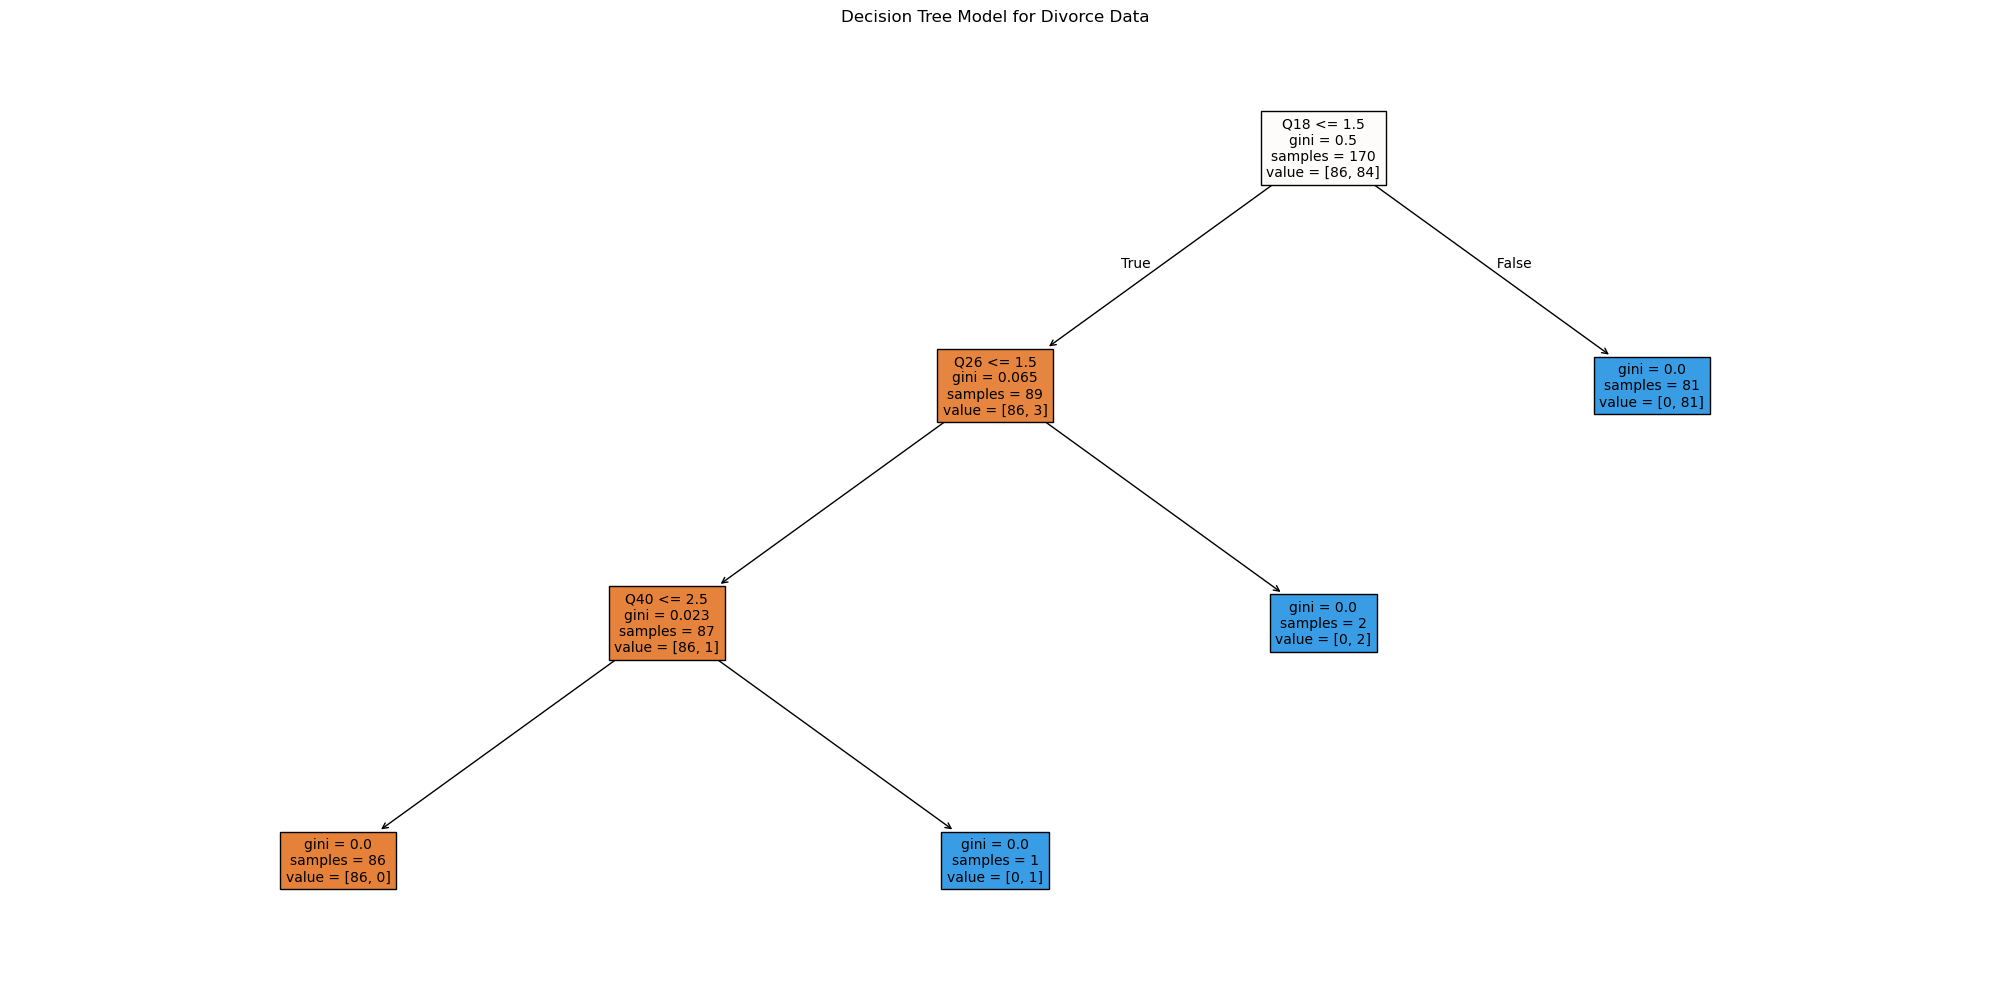

In [ ]:
# Imports for SKLEARN tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree


# Set up features and target variable
X = divorce_df.drop('Divorce', axis=1)
y = divorce_df['Divorce']

var_names = list(X.columns)

# Create a default tree for the full data set
cart = DecisionTreeClassifier()
cart = cart.fit(X, y)

# Visualize the tree
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(cart, filled=True, fontsize=10, feature_names=var_names, ax=ax)
plt.title('Decision Tree Model for Divorce Data')
plt.tight_layout()
plt.show()

### Looking at the Identified Questions

- Decision trees are typically represented with a *dendrogram*, the plot above. They are are a popular way of visualizing hierarchical or acyclic relationships.

- Interpreting the output:
  - The first line in each box is the classificaiton criteria. For example, the first split is based on Q18 asking if the value is less than or equal to 1.5. If True, you go left. If false, you go right.
  - **gini**: The Gini Impurity at that current data split. We'll discuss this extensively later in the notebook. This is our error function.
  - **samples**: The number of samples that "reach" that node or are in the subset.
  - **value**: The number of samples in each of the classes at that node.

- Looking at the dendrogram, we can identify which variables were selected for the fitting process:
    - Q18. My spouse and I have similar ideas about how marriage should be (High value predicts divorce)
    - Q26. I know my spouse's basic concerns. (High value predicts divorce)
    - Q40. We are just starting a fight before I know what is going on. (High value predicts divorce)
- Seems about right? Maybe the last question is overfitting?

### Did it "work"?: Greedy Algorithm and the Need of Train/Test Split

- Before we go under the hood of the algorithm, we might want to think a bit about what "good performance" means.

- Like with $k$MC or $k$NN, this is a **greedy** kind of algorithm:
  - Left to its own devices, it searches for a perfect split of the data, where the terminal nodes are as pure as possible in terms of classification.

- In practice, this often means that it is a perfect predictor on the training data.

- In situations like this, we are in the familiar situation of having to split into **training and testing data** in order to be able to make sense of the question, "How well is the algorithm performing?"

## The Confusion Matrix
- The analog of `SSE` for classification is, roughly the **confusion matrix**
-  We cross tabulate the actual values for the predicted and true values:

|  | Predicted Negative | Predicted Positive|
| :---: | :---:| :---: |
| Actual Negative | True Negative (TN) | False Positive (FP) |
| Actual Positive | False Negative (FN) | True Positive (TP) |

- The definions of each of these terms is listed below. The *True/False* indicates whether the prediction was correct or incorrect. The *Negative/Positive* reflects whether we **predicted** the negative of positive class:
  - **True Negative:** A case when we predict that the class is negative and the true class is negative.
  - **True Positive:** A case when we predict that the class is positive and the true calss is positive.
  - **False Negative:** A case when we predict that the class is negative but the true class is actually positive.
  - **False Positive:** A case when we predict that the class is positive but the true class is actually negative.

- The simplest metric of success with a confusion table is **Accuracy**: The proportion of predictions that were correct, or
$$ \text{Accuracy} = \dfrac{TN+TP}{TN+FP+FN+TP} $$
Later, we'll talk about the hundreds of other such metrics.

In [ ]:
from sklearn.model_selection import train_test_split


# Compute an 80/20 train/test split on the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit a decision tree on the train data and test on the test data
cart_split = DecisionTreeClassifier()
cart_split = cart_split.fit(X_train, y_train)

# Generate predictions on the test set
y_pred = cart_split.predict(X_test)

In [ ]:

# Look at the confusion matrix for our test predictions
confusion = pd.crosstab(y_test, y_pred, rownames=['Actual'], colnames=['Predicted'])
print(confusion)

Predicted   0   1
Actual           
0          13   1
1           1  19


In [ ]:

# Compute the accuracy using the values in the cross tab
TN = confusion.iloc[0, 0]
FP = confusion.iloc[0, 1] if confusion.shape[1] > 1 else 0
FN = confusion.iloc[1, 0] if confusion.shape[0] > 1 else 0
TP = confusion.iloc[1, 1] if confusion.shape == (2, 2) else 0

accuracy = (TN + TP) / (TN + FP + FN + TP)
print(f'True Negatives (TN): {TN}')
print(f'False Positives (FP): {FP}')
print(f'False Negatives (FN): {FN}')
print(f'True Positives (TP): {TP}')
print(f'Accuracy: {accuracy:.4f}')

True Negatives (TN): 13
False Positives (FP): 1
False Negatives (FN): 1
True Positives (TP): 19
Accuracy: 0.9412


### Analyzing and Improving Performance

- Since the first question is so diagnostically powerful, the accuracy of the tree is around 91.2%

- If the performance of the tree was unsatisfactory on the test set, there are things we could do:
    - If we think the tree is **overfitting**, we could truncate the tree and limit its depth, so that it isn't making splits on very fine distinctions among a handful of observations

    - If we think the tree is **underfitting**, we could program it to avoid making splits that make the subsequent populations too pure, so that it has to use more questions and provide a richer and more complex tree

### Examples When Trees Are Useful
- Diagnostic tests in medical settings (symptoms/test results $\rightarrow$ diagnosis).
- Any situation where most of the data are mostly categorical rather than numeric.
- High-dimensional data where variable selection for linear model is too difficult or where the arbitrariness of the distance metric in $k$NN is a concern.

## How do Decision Trees Decide How to Split the Data?

- To understand the mechanics of building a tree, we need to think about "splitting" data.

- In the divorce situation, imagine you are trying to use a particular question, say $Q18$, to split the respondents $i = 1, ..., N$ into two groups (Non-divorced vs divorced).

- As you vary the cutoff response from 1 to 3, you break the $N$ respondents into two groups: Those strictly below the cutoff and those weakly above it
    - Cutoff at 1: $\{0\}$ and $\{1, 2, 3, 4\}$
    - Cutoff at 2: $\{0,1\}$ and $\{2,3,4\}$
    - Cutoff at 3: $\{0,1,2\}$ and $\{3,4\}$
    - Cutoff at 4: $\{0,1,2,3\}$ and $\{4\}$

- Let's look at the frequencies in the bins for $Q18$ for an example

In [12]:
# Create a cross tab for the outcome variable and the responses to question 18
pd.crosstab(y, X.iloc[:,17])

Q18,0,1,2,3,4
Divorce,,,,,
0,78,8,0,0,0
1,1,2,16,44,21


### Comparing the Splits of this Example
- As you vary the cutoff, what is the proportion of couples strictly below and weakly above the cutoff that divorce?
  - With a cutoff of 1, the divorce proportion for $\{0\}$ is $1/79= .013$, but for $\{1,2,3,4\}$ it's $83/91 = .912$.
  - With a cutoff of 2, the divorce proportion for $\{0,1\}$ is $3/89=.034$, but for $\{2,3,4\}$ it's $81/81=1$.
  - With a cutoff of 3, the divorce proportion for $\{0,1,2\}$ is $19/105=.181$, but for $\{3,4\}$ it's $65/65=1$.
  - With a cutoff of 4, the divorce proportion for $\{0,1,2,3\}$ is $63/149=.423$, but for $\{4\}$ it's $21/21=1$.

- Putting this into a table:
| Cutoff Value | Class 0 Proportion | Class 1 Proportion |
| ------------ | ------------------ | ------------------ |
| 1 | 0.013 | 0.912 |
| 2 | 0.034 | 1 |
| 3 | 0.181 | 1 |
| 4 | 0.423 | 1 |
- Which splits result in two groups are "most alike"? Which are "most different"?

### Creating an Error Function that Maximizes the Difference Between Groups
- What we want is to create groups that are "as different as possible" from each other
  - Ideally, one group would have 0% divorces and the other would have 100% divorces: That's a perfect predictor.

- What we do not want is groups that have similar proportions to one another
  - If one group is 50% and the other is 50%, our predictor/split is not distinguishing the two groups at all.

- So our "ideal error" curve would be largest and single-peaked at 1/2, 0 at 0, 0 at 1, and otherwise smooth/continuous.

- **Gini Impurity**: $x(1-x)$ is the easiest way to do this

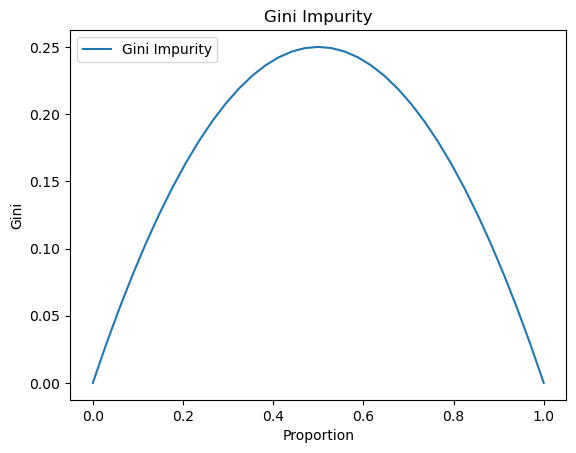

In [13]:
# Plot the Gini Impurity Function

# Define x values that go from 0 to 1
# Reflecting different probabilities
x = np.linspace(0,1,35)
y = x*(1-x)

# Plot the result
plt.plot(x,y, label ='Gini Impurity')
plt.xlabel("Proportion")
plt.ylabel("Gini")
plt.legend(loc='upper left')
plt.title('Gini Impurity')
plt.show()

### Computing the Gini Impurity For Q18

- For each group $g$ created by the split, we compute the proportion of divorces, $p_g$, the Gini Impurity given this probability ($p_g(1-p_g)$), and sum over the groups $g$. Doing this for the example with Q18:

```{r}
.013*(1-.013) + .912*(1-.912) # Split into {0}, {1,2,3,4}
.034*(1-.034) + 1*(1-1) # Split into {0,1}, {2,3,4}
.181*(1-.181) + 1*(1-1) # Split into {0,1,2}, {3,4}
.423*(1-.423) + 1*(1-1) # Split into {0,1,3,4}, {4}
```

- Let's implement this process in Python.

In [14]:
# Calculating the Gini Impurity for Each Split
# Using the probabilties we calculated earlier

s1 = .013*(1-.013) + .912*(1-.912) # Split into {0}, {1,2,3,4}
s2 = .034*(1-.034) + 1*(1-1) # Split into {0,1}, {2,3,4}
s3 = .181*(1-.181) + 1*(1-1) # Split into {0,1,2}, {3,4}
s4 = .423*(1-.423) + 1*(1-1) # Split into {0,1,3,4}, {4}

# Printing the result to identify which split produces the smallest Gini Impurity
print('Splitting On 1:', s1)
print('Splitting On 2:', s2)
print('Splitting On 3:', s3)
print('Splitting On 4:', s4)

Splitting On 1: 0.09308699999999996
Splitting On 2: 0.032844
Splitting On 3: 0.14823899999999998
Splitting On 4: 0.24407099999999998


- **The split with the lowest Gini impurity is 2**. This was the first split in the decision tree at the beginning of the lecture.

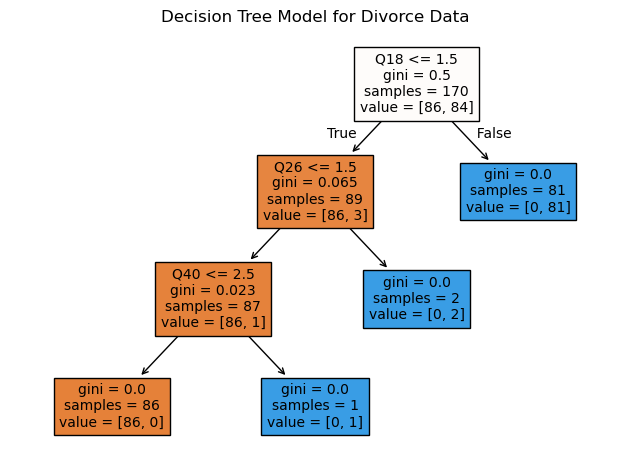

In [15]:
# Compare with the tree again, notice that the first split is less than / equal to 1.5,
# which is equivalent to less than 2.
plot_tree(
    cart, filled=True,
    fontsize = 10, feature_names = var_names
)
plt.title('Decision Tree Model for Divorce Data')
plt.tight_layout()
plt.show()

### The Divorce Example: Subsequent Splits

- This split gives us two different subsets now. We can create additional splits on these subsets.

- If $Q18$ is greater than 2, all of those couples get divorced. This means there's no further learning to do on this side of the split.

- If $Q18$ is strictly less than 2, there are still divorces. This means that we can repeat the process, splitting the subpopulation to minimize the Gini impurity.

- $Q26$ is the next question that is optimal to split on, but in principle we would look at all the possible variables (including ones previously used).

In [24]:

# Look at the cross tab of the subsection where Q18 is less than 2
q18_below_2_idx = X['Q18'] < 2
pd.crosstab(y[q18_below_2_idx], X[q18_below_2_idx]['Q26'])

IndexError: boolean index did not match indexed array along axis 0; size of axis is 35 but size of corresponding boolean axis is 170

In [23]:

# We can compute the gini impurity for the difference in classes within this split
q18_below_2_idx = X['Q18'] < 2
y_sub = y[q18_below_2_idx]
X_sub = X[q18_below_2_idx]

# Compute the gini impurity for each possible split of Q26
for cutoff in [1, 2, 3, 4]:
    below = y_sub[X_sub['Q26'] < cutoff]
    above = y_sub[X_sub['Q26'] >= cutoff]

    p_below = below.mean() if len(below) > 0 else 0
    p_above = above.mean() if len(above) > 0 else 0

    gini = p_below * (1 - p_below) + p_above * (1 - p_above)
    print(f'Cutoff at {cutoff}: Gini Impurity = {gini:.4f}')

IndexError: boolean index did not match indexed array along axis 0; size of axis is 35 but size of corresponding boolean axis is 170

From this table, we can see that a split should be made when **Q26 < 2**. This is what we can see from the tree before.

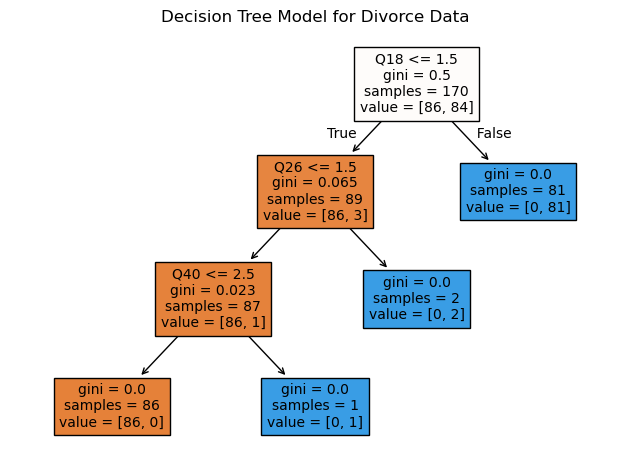

In [18]:
# Compare with the tree again, notice that
plot_tree(
    cart, filled=True,
    fontsize = 10, feature_names = var_names
)
plt.title('Decision Tree Model for Divorce Data')
plt.tight_layout()
plt.show()

**You can look at this split for all of the variables, including the ones we've used already**

In [19]:
# Index where Q18 response is less than 2
q18_above_2_idx = X['Q18'] < 2

# Isolate out using our index
y_k = y[q18_above_2_idx]

# Loop over all of predictive columns
for k in range( X.shape[1]):
  # Isolate out the column of interest in our subset
  X_k = X[q18_above_2_idx].iloc[:, k]

  # Print the cross table
  print(pd.crosstab( y_k, X_k ), '\n')

IndexError: boolean index did not match indexed array along axis 0; size of axis is 35 but size of corresponding boolean axis is 170

- We can look through our remaining predictors to determine if there is one that can best further split the sub-population.

- This iterative process creates a multi-step prediction algorithm, called a *classification/regression tree* or *decision tree*

### Growing Decision Trees: How to Fit
- Building the predictive model iterates on the previous steps:
  1. For all of the variables, determine the split for each that minimizes Gini impurity
  2. Pick the variable that achieves the lowest Gini impurity overall. This creates a single split in the tree. (We might use this variable again to build the tree.)
  3. Repeat steps 1 and 2 *for each of the sub-populations created by our previous splits* until the impurity is 0 for the remaining sub-populations (they are perfectly separated by outcome)

### Defining Stopping Rules to Prevent Overfitting
- Often, additional stopping rules are imposed to keep the decision tree from too greedily using data. These are attributes that we can include in creating the model instance in sklearn:

  - **max_depth:** Impose a limit on the depth of the tree. This is the maximum length of a path from the top to the bottom.

  - **min_impurity_decrease**: Impose a theshold on how much the Gini impurity should decrease with a split. This makes it so that the terminal nodes don't become "too pure" and so that more impactful splits are included.

  - **min_samples_leaf**: Impose a limit on how few cases can appear at a terminal node. This makes sure that the terminal nodes aren't "too small".

- Just as with the other algorithms, we would like to make this a more data-driven decision (we'll get to that).

- If we are using the algorithm repeatedly in practice, we can "prune" back parts of the tree that are unreliable or augment them with new training data.

**Question:** What is the default value for **max_depth** in the sklearn decision tree function?

In [ ]:

# Create a decision tree with different values of max_depth
# Default max_depth=None (grows until all leaves are pure or contain min_samples_split samples)

for depth in [None, 1, 2, 3]:
    # Fit decision tree:
    cart = DecisionTreeClassifier(max_depth=depth)  # Create a classifier object
    cart = cart.fit(X, y)  # Fit the classifier

    # Visualize results:
    fig, ax = plt.subplots(figsize=(20, 8))
    plot_tree(cart, filled=True, fontsize=10, feature_names=var_names, ax=ax)
    plt.title(f'Decision Tree Model for Divorce Data (max_depth={depth})')
    plt.tight_layout()
    plt.show()
    print(f'max_depth={depth} | Tree depth: {cart.get_depth()} | Leaves: {cart.get_n_leaves()}\n')

ValueError: Unknown label type: continuous. Maybe you are trying to fit a classifier, which expects discrete classes on a regression target with continuous values.

**Question:** What is the default value for **min_impurity_decrease** in the sklearn decision tree function?


by default the min_ipurity decerase is 0. Ther'es no limit on how small fo a decrease can occur.

In [ ]:

# Create a decision tree with different values of min_impurity_decrease
# Default min_impurity_decrease=0.0 (any split that reduces impurity is accepted)

for min_impurity in [0.0, 0.01, 0.05, 0.1]:
    # Fit decision tree:
    cart = DecisionTreeClassifier(min_impurity_decrease=min_impurity)  # Create a classifier object
    cart = cart.fit(X, y)  # Fit the classifier

    # Visualize results:
    fig, ax = plt.subplots(figsize=(20, 8))
    plot_tree(cart, filled=True, fontsize=10, feature_names=var_names, ax=ax)
    plt.title(f'Decision Tree Model for Divorce Data (min_impurity_decrease={min_impurity})')
    plt.tight_layout()
    plt.show()
    print(f'min_impurity_decrease={min_impurity} | Tree depth: {cart.get_depth()} | Leaves: {cart.get_n_leaves()}\n')

ValueError: Unknown label type: continuous. Maybe you are trying to fit a classifier, which expects discrete classes on a regression target with continuous values.

**Question:** What is the default value for **min_samples_leaf** in the sklearn decision tree function?


In [25]:

# Create a decision tree with different values of min_samples_leaf
# Default min_samples_leaf=1 (a leaf can contain a single sample)

for min_leaf in [1, 5, 10, 20]:
    # Fit decision tree:
    cart = DecisionTreeClassifier(min_samples_leaf=min_leaf)  # Create a classifier object
    cart = cart.fit(X, y)  # Fit the classifier

    # Visualize results:
    fig, ax = plt.subplots(figsize=(20, 8))
    plot_tree(cart, filled=True, fontsize=10, feature_names=var_names, ax=ax)
    plt.title(f'Decision Tree Model for Divorce Data (min_samples_leaf={min_leaf})')
    plt.tight_layout()
    plt.show()
    print(f'min_samples_leaf={min_leaf} | Tree depth: {cart.get_depth()} | Leaves: {cart.get_n_leaves()}\n')

ValueError: Unknown label type: continuous. Maybe you are trying to fit a classifier, which expects discrete classes on a regression target with continuous values.

### Classification with Multiple Outcomes Instead of Just Binary

- In our example, Divorce was binary; in many situations, the outcome might have many categorical possibilities (non-cancerous/benign/malignant, bond ratings, etc.)

- In this case, we add additional terms to the impurity measure that correspond to each category.

- Imagine a split creates groups $g=1, 2, ..., G$ over the categories $j=1, 2, ..., J$. Let $p_{jg}$ be the proportion of outcomes in group $g$ that take the value $j$
  - g: The groups created by the split (ex. Q18 response less than 1.5 and Q18 response greater than 2 are the groups).
  - j: The outcome categories that an observation can have. For divorce, this was 0 or 1. Multiclass introduce additional categories.

- For each of the groups $g$ created by the split and each of the categories $j$ that occur in the target/outcome/dependent variable, we compute the Gini impurity $p_{jg}(1-p_{jg})$, then we sum over all groups and categories.

- Formally, we split to minimize
$$
\sum_{g=1}^G \sum_{j =1}^J p_{jg}(1-p_{jg})
$$

## Entropy: An Alternative to Gini Impurity

- There are, unsurprisingly, dozens of algorithms and approaches to creating decision-trees.

- The Gini Impurity is a completely valid way to approach the measurement of how "mixed" or "impure" a split is.

- Many algorithms default to using *entropy* rather than *gini impurity*.

- **Entropy** is defined as defined as
$$
\sum_g - p_g \log_2(p_g)
$$

with the convention that $0 \log_2(0) = 0$.

- Mathematically and practically, the Gini Impurity and Entropy Measures are very similar.

- Entropy is a complex concept that tries to measure how much "disorder" there is in a system, or how much information you would need to describe its state; its additional mathematical properties motivate its use in decision trees

## Conclusion: Decision Trees
- **Many variations on trees:** There are dozens of variations on this concept (e.g. ID3, C4.5, CART).
- **Trees are highly non-linear:** Trees express highly non-linear relationships between target variables and data. This can be an advantage in some situations over linear models.
- **Trees are interpretable:** With the dendrogram, we have a clear understanding of why we achieve our end prediction. Many people like how "interpretable" trees are. This can be an advantage over $k$NN.
- **Trees can easily overfit to data if we're not cautious:** They are famously sensitive to the data (a later algorithm, *random forests*, will address this problem).
- **Discrete splits can be beneficial:** They are based on discrete splits. This is simple but works very well on "chunky"/"unitless" data like the divorce Likert scale questions
- Prediction can be a challenge if the resulting model is "too simple". Imagine a therapist asking two questions, telling you to get divorced, and asking for payment.